# Exploratory Data Analysis — Carbon Intensity & Renewable Fraction
## Thesis: Carbon-Intelligent Workload Scheduling for AI Data Centers
**Author**: Yaxin (Isabel) Wu | **Supervisor**: Prof. Bissan Ghaddar | IE University, 2026

---

### Overview
This notebook performs EDA on hourly Carbon Intensity (CI) and Renewable Fraction (RF) data retrieved from the ElectricityMaps API for five target grid regions: **PJM, NYISO, Finland, Belgium, and Singapore**, covering **2024–2025** (17,521 hours per region).

The analysis proceeds in the following steps:
1. Data loading and basic inspection
2. Data quality checks & cleaning (nulls, duplicates, gaps, plausibility)
3. Descriptive statistics
4. CI Variability (CV) — a post-hoc diagnostic computed from the full historical series
5. CI distribution by region
6. CI time series and seasonal patterns
7. Diurnal patterns (average CI by hour of day)
8. Renewable Fraction (RF) analysis
9. CI–RF relationship — validating the objective function construction
10. Summary of findings and implications for the optimization model

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# Region metadata
ZONES = {
    "US-MIDA-PJM": {"label": "PJM",       "color": "#e05c5c"},
    "US-NY-NYIS":  {"label": "NYISO",     "color": "#e08c3a"},
    "FI":          {"label": "Finland",   "color": "#5ca85c"},
    "BE":          {"label": "Belgium",   "color": "#5c7ae0"},
    "SG":          {"label": "Singapore", "color": "#9b59b6"},
}

print("Imports OK")

Imports OK


---
## 2. Data Loading

We load the pre-fetched `.parquet` files for each zone and merge CI and RF into a single DataFrame per region. The `datetime` column is parsed to UTC-aware timestamps and used as the index throughout the analysis.

In [2]:
import os

data = {}
for zone, meta in ZONES.items():
    ci = pd.read_parquet(f"../data/raw/{zone}_ci.parquet")
    rf = pd.read_parquet(f"../data/raw/{zone}_rf.parquet")

    df = pd.merge(ci, rf, on="datetime", how="inner")
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
    df = df.set_index("datetime").sort_index()
    df.columns = ["ci", "rf"]
    df["zone"] = meta["label"]
    data[zone] = df

# Quick sanity check
for zone, df in data.items():
    print(f"{ZONES[zone]['label']:10}  rows={len(df):,}  CI_null={df['ci'].isna().sum()}  "
          f"RF_null={df['rf'].isna().sum()}  "
          f"range={df.index.min().date()} → {df.index.max().date()}")

PJM         rows=17,544  CI_null=0  RF_null=0  range=2024-01-01 → 2025-12-31
NYISO       rows=17,544  CI_null=0  RF_null=0  range=2024-01-01 → 2025-12-31
Finland     rows=17,544  CI_null=0  RF_null=0  range=2024-01-01 → 2025-12-31
Belgium     rows=17,544  CI_null=0  RF_null=0  range=2024-01-01 → 2025-12-31
Singapore   rows=17,544  CI_null=0  RF_null=0  range=2024-01-01 → 2025-12-31


---
## 3. Data Quality Checks & Cleaning

Before any analysis, we systematically verify data integrity across four dimensions:

1. **Explicit missing values** — NaN in CI or RF columns
2. **Duplicate timestamps** — same datetime appearing more than once
3. **Time series continuity** — gaps in the expected hourly sequence (implicit missing hours)
4. **Physical plausibility** — values outside valid ranges (CI < 0 or > 1,000 gCO₂/kWh; RF outside [0, 1])

Any issues found here would require imputation or removal before the data enters the optimization model. Results are documented regardless of outcome — a clean dataset still needs proof of cleanliness.

In [3]:
issues = []

for zone, df in data.items():
    label = ZONES[zone]["label"]

    # 1. Explicit nulls
    ci_null = df["ci"].isna().sum()
    rf_null = df["rf"].isna().sum()

    # 2. Duplicate timestamps
    dupes = df.index.duplicated().sum()

    # 3. Time series continuity — expected hourly index vs actual
    expected = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h", tz="UTC")
    missing_hours = expected.difference(df.index)

    # 4. Physical plausibility
    ci_negative  = (df["ci"] < 0).sum()
    ci_too_high  = (df["ci"] > 1000).sum()
    rf_below_zero = (df["rf"] < 0).sum()
    rf_above_one  = (df["rf"] > 1).sum()

    issues.append({
        "Region":          label,
        "CI nulls":        ci_null,
        "RF nulls":        rf_null,
        "Duplicate ts":    dupes,
        "Missing hours":   len(missing_hours),
        "CI < 0":          ci_negative,
        "CI > 1000":       ci_too_high,
        "RF < 0":          rf_below_zero,
        "RF > 1":          rf_above_one,
    })

qc = pd.DataFrame(issues).set_index("Region")
print("=== Data Quality Report ===")
print(qc.to_string())

total_issues = qc.drop(columns=[]).values.sum()
print(f"\nTotal issues found: {total_issues}")
if total_issues == 0:
    print("✓ All checks passed — dataset is clean and ready for analysis.")

=== Data Quality Report ===
           CI nulls  RF nulls  Duplicate ts  Missing hours  CI < 0  CI > 1000  RF < 0  RF > 1
Region                                                                                       
PJM               0         0             0              0       0          0       0       0
NYISO             0         0             0              0       0          0       0       0
Finland           0         0             0              0       0          0       0       0
Belgium           0         0             0              0       0          0       0       0
Singapore         0         0             0              0       0          0       0       0

Total issues found: 0
✓ All checks passed — dataset is clean and ready for analysis.


In [4]:
# Cleaning actions — applied if any issues are found
# If all checks passed above, this cell confirms no action was needed.

for zone, df in data.items():
    label = ZONES[zone]["label"]
    original_len = len(df)

    # Remove duplicate timestamps (keep first)
    df = df[~df.index.duplicated(keep="first")]

    # Reindex to full hourly range and forward-fill gaps ≤ 2 hours
    # (short gaps from API delays are acceptable; longer gaps would require investigation)
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h", tz="UTC")
    df = df.reindex(full_idx)
    gap_count = df["ci"].isna().sum()
    if gap_count > 0:
        df = df.fillna(method="ffill", limit=2)
        remaining = df["ci"].isna().sum()
        print(f"{label}: filled {gap_count} gap(s) via forward-fill; {remaining} remaining NaN(s)")
    
    # Clip physically implausible values
    df["ci"] = df["ci"].clip(lower=0, upper=1000)
    df["rf"] = df["rf"].clip(lower=0, upper=1)

    data[zone] = df
    if len(df) != original_len or gap_count > 0:
        print(f"{label}: rows {original_len} → {len(df)}")

print("Cleaning complete. Final row counts:")
for zone, df in data.items():
    print(f"  {ZONES[zone]['label']:10}  {len(df):,} rows")

Cleaning complete. Final row counts:
  PJM         17,544 rows
  NYISO       17,544 rows
  Finland     17,544 rows
  Belgium     17,544 rows
  Singapore   17,544 rows


---
## 3. Descriptive Statistics

We compute per-region summary statistics for CI (gCO₂eq/kWh) and RF (%). These numbers directly inform the optimization model: a high CI mean signals a carbon-intensive grid; a high CI std signals strong temporal shifting potential.

In [5]:
rows = []
for zone, df in data.items():
    rows.append({
        "Region":   ZONES[zone]["label"],
        "CI mean":  round(df["ci"].mean(), 1),
        "CI std":   round(df["ci"].std(), 1),
        "CI min":   int(df["ci"].min()),
        "CI max":   int(df["ci"].max()),
        "CI p25":   int(df["ci"].quantile(0.25)),
        "CI p75":   int(df["ci"].quantile(0.75)),
        "RF mean %": round(df["rf"].mean() * 100, 1),
        "RF std %":  round(df["rf"].std() * 100, 1),
    })

stats = pd.DataFrame(rows).set_index("Region")
stats

,CI mean,CI std,CI min,CI max,CI p25,CI p75,RF mean %,RF std %
Region,,,,,,,,
PJM,472.2,52.1,313,627,435,508,7.7,3.7
NYISO,353.7,44.2,215,499,325,383,25.2,5.6
Finland,82.7,34.7,34,285,57,100,58.6,6.7
Belgium,191.2,76.1,69,433,132,241,38.3,16.7
Singapore,533.2,59.8,391,584,511,578,2.7,3.9


---
## 4. CI Variability (CV) — Post-hoc Regional Diagnostic

**CV (Coefficient of Variation)** = σ(CI) / μ(CI) is computed from the full 2024–2025 historical series after data collection. It is not an input to the LP — incorporating a historical aggregate statistic into the objective would compromise the model's deterministic structure, since CV is only knowable after observing the entire time series.

Instead, CV is used as a post-hoc diagnostic: after backtesting, it explains why carbon savings vary across regions. Regions with high CI fluctuation (high CV) offer more room for temporal shifting, while regions with stable CI (low CV, e.g. Singapore) yield limited benefit regardless of the scheduling policy.

               CV Scheduling opportunity
Finland    0.4198                Highest
Belgium    0.3980                   High
NYISO      0.1250                 Medium
Singapore  0.1121                 Medium
PJM        0.1104                 Lowest


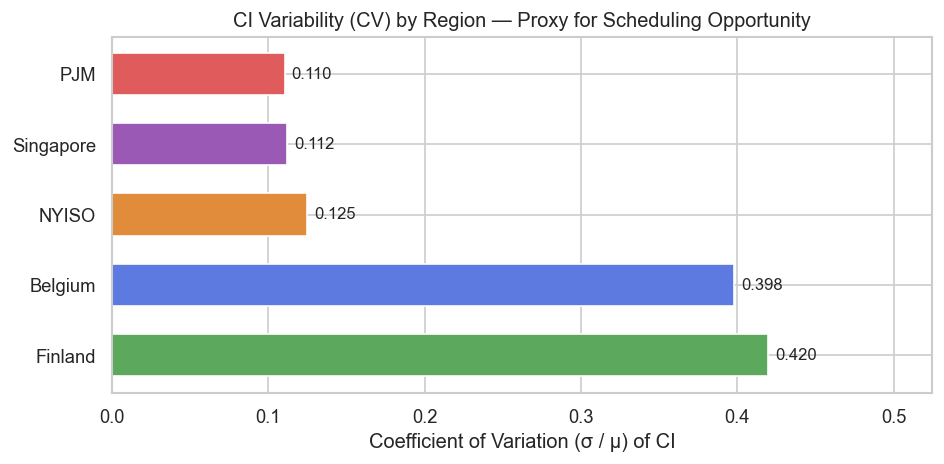

In [6]:
cv_data = {ZONES[z]["label"]: round(data[z]["ci"].std() / data[z]["ci"].mean(), 4) for z in ZONES}
cv_df = pd.Series(cv_data, name="CV").sort_values(ascending=False).to_frame()
cv_df["Scheduling opportunity"] = ["Highest", "High", "Medium", "Medium", "Lowest"]
print(cv_df)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [ZONES[z]["color"] for z in sorted(ZONES, key=lambda z: -data[z]["ci"].std()/data[z]["ci"].mean())]
bars = ax.barh(cv_df.index, cv_df["CV"], color=colors, edgecolor="white", height=0.6)
ax.set_xlabel("Coefficient of Variation (σ / μ) of CI")
ax.set_title("CI Variability (CV) by Region — Proxy for Scheduling Opportunity")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xlim(0, cv_df["CV"].max() * 1.25)
plt.tight_layout()
plt.savefig("../data/figures/eda_cv.png", bbox_inches="tight")
plt.show()

---
## 5. CI Distribution by Region

Boxplots and violin plots reveal the full distribution shape of CI per region. Wide IQR indicates high intra-region variability (PJM, NYISO). Finland shows a right-skewed distribution driven by seasonal nuclear + hydro variation. Singapore's narrow distribution confirms minimal temporal shifting opportunity.

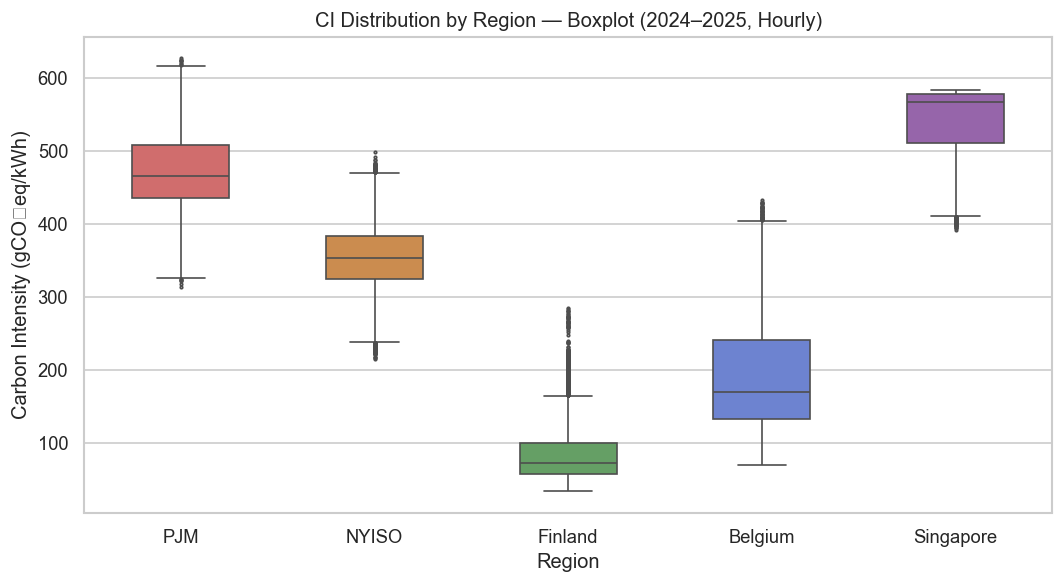

In [7]:
all_df = pd.concat([df[["ci", "zone"]] for df in data.values()])
zone_order = [ZONES[z]["label"] for z in ZONES]
palette = {ZONES[z]["label"]: ZONES[z]["color"] for z in ZONES}

# Figure 1: Boxplot
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=all_df, x="zone", y="ci", order=zone_order,
            palette=palette, width=0.5, fliersize=1.5, ax=ax)
ax.set_title("CI Distribution by Region — Boxplot (2024–2025, Hourly)")
ax.set_xlabel("Region")
ax.set_ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_boxplot.png", bbox_inches="tight")
plt.show()

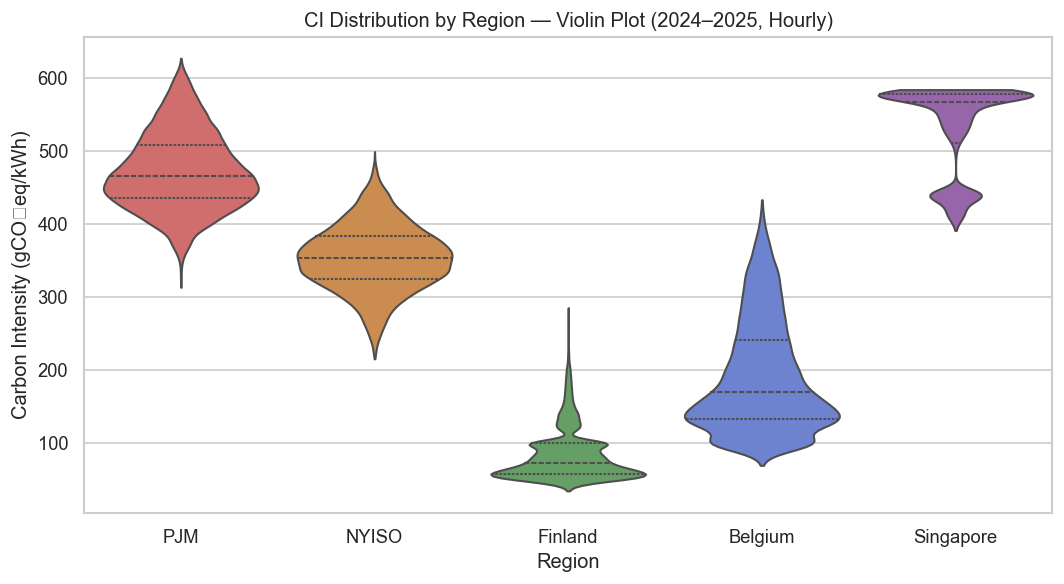

In [8]:
# Figure 2: Violin plot
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=all_df, x="zone", y="ci", order=zone_order,
               palette=palette, inner="quartile", cut=0, ax=ax)
ax.set_title("CI Distribution by Region — Violin Plot (2024–2025, Hourly)")
ax.set_xlabel("Region")
ax.set_ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_violin.png", bbox_inches="tight")
plt.show()

---
## 6. CI Time Series (Monthly Averages)

To visualize long-run trends, we plot monthly-averaged CI for each region. This reveals seasonal structure: Finland's CI drops sharply in summer (hydro + wind peak); PJM shows mild summer peaks from air-conditioning demand driving more gas generation. These seasonal patterns motivate the need for a full 2-year dataset rather than a single snapshot.

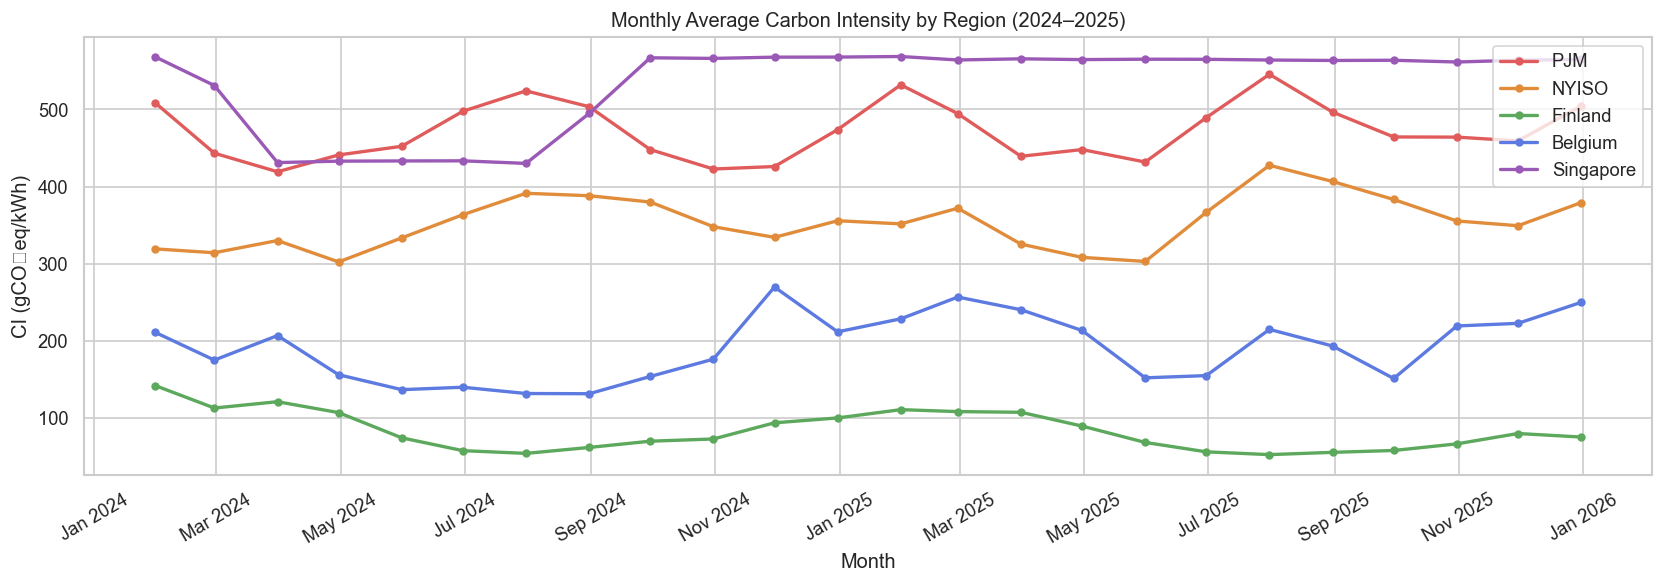

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

for zone, df in data.items():
    monthly = df["ci"].resample("ME").mean()
    ax.plot(monthly.index, monthly.values,
            label=ZONES[zone]["label"],
            color=ZONES[zone]["color"],
            linewidth=2, marker="o", markersize=4)

ax.set_title("Monthly Average Carbon Intensity by Region (2024–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("CI (gCO₂eq/kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_timeseries.png", bbox_inches="tight")
plt.show()

---
## 7. Diurnal Patterns — Average CI by Hour of Day

Intra-day CI patterns are the primary driver of **temporal shifting** decisions. A large gap between peak-hour and trough-hour CI creates opportunities to defer flexible AI workloads to cleaner windows. We compute the average CI for each hour of the day (UTC) across the full 2-year dataset.

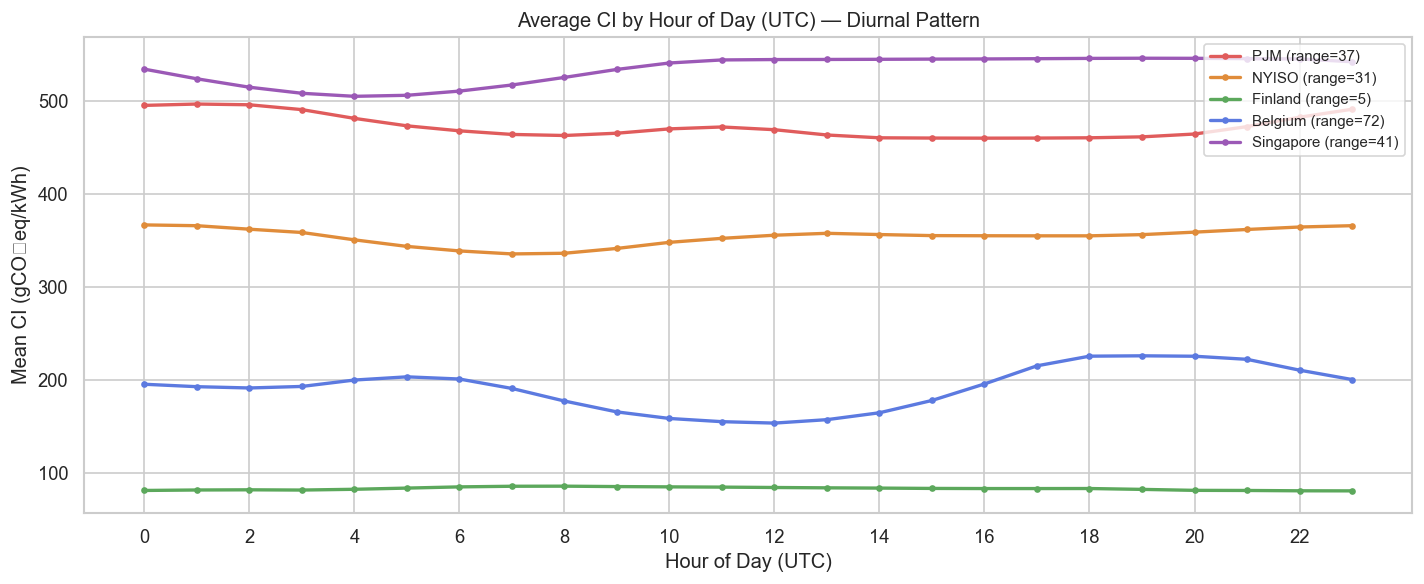


Diurnal range (max - min avg CI by hour):
  PJM         36.7 gCO₂/kWh
  NYISO       31.2 gCO₂/kWh
  Finland     5.1 gCO₂/kWh
  Belgium     72.4 gCO₂/kWh
  Singapore   41.0 gCO₂/kWh


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

for zone, df in data.items():
    hourly = df["ci"].groupby(df.index.hour).mean()
    diurnal_range = hourly.max() - hourly.min()
    ax.plot(hourly.index, hourly.values,
            label=f"{ZONES[zone]['label']} (range={diurnal_range:.0f})",
            color=ZONES[zone]["color"], linewidth=2, marker="o", markersize=3)

ax.set_title("Average CI by Hour of Day (UTC) — Diurnal Pattern")
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Mean CI (gCO₂eq/kWh)")
ax.set_xticks(range(0, 24, 2))
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("../data/figures/eda_diurnal.png", bbox_inches="tight")
plt.show()

print("\nDiurnal range (max - min avg CI by hour):")
for zone, df in data.items():
    hourly = df["ci"].groupby(df.index.hour).mean()
    print(f"  {ZONES[zone]['label']:10}  {hourly.max() - hourly.min():.1f} gCO₂/kWh")

---
## 8. Seasonal Patterns — Average CI by Month

Seasonal variation drives **long-horizon temporal shifting** and explains why Finland's CI distribution is right-skewed despite its very low annual mean. We compute mean CI per calendar month to expose these patterns.

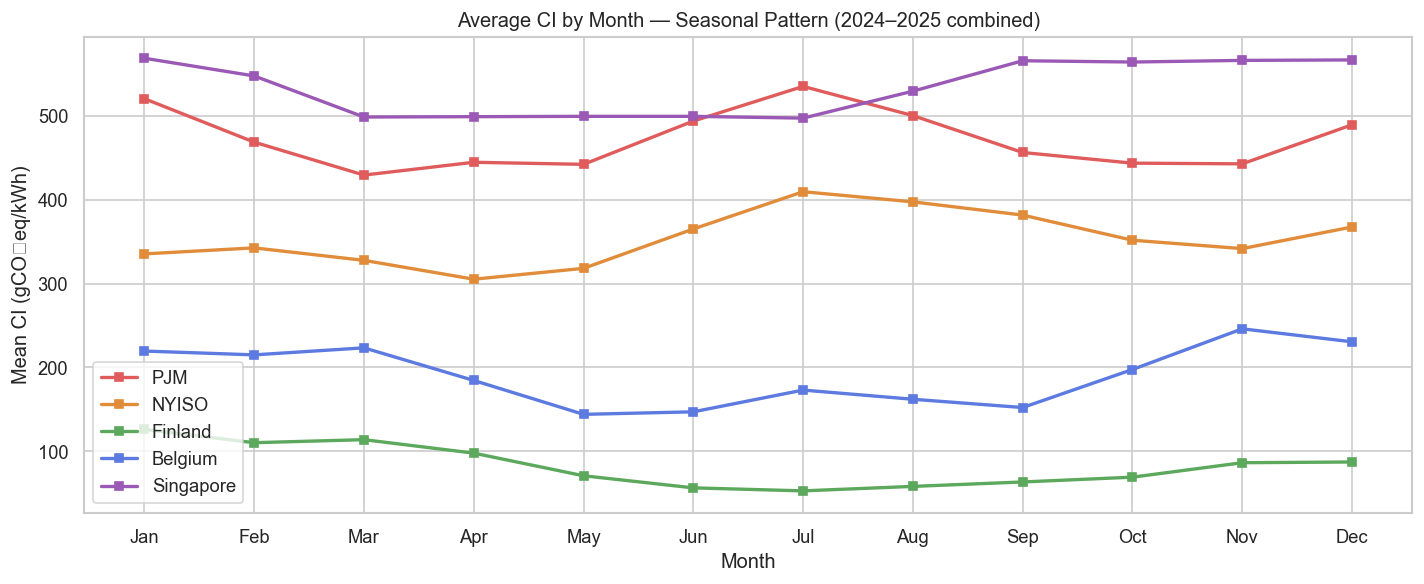

In [11]:
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(12, 5))

for zone, df in data.items():
    monthly = df["ci"].groupby(df.index.month).mean()
    ax.plot(monthly.index, monthly.values,
            label=ZONES[zone]["label"],
            color=ZONES[zone]["color"], linewidth=2, marker="s", markersize=5)

ax.set_title("Average CI by Month — Seasonal Pattern (2024–2025 combined)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean CI (gCO₂eq/kWh)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.legend()
plt.tight_layout()
plt.savefig("../data/figures/eda_seasonal.png", bbox_inches="tight")
plt.show()

---
## 9. Renewable Fraction (RF) Analysis

RF enters the objective function as the weighting term `(1 − α·RF(t))`, reducing the effective carbon cost in hours with high renewable generation. Here we examine RF distributions and its intra-day pattern to understand when the model will preferentially schedule workloads.

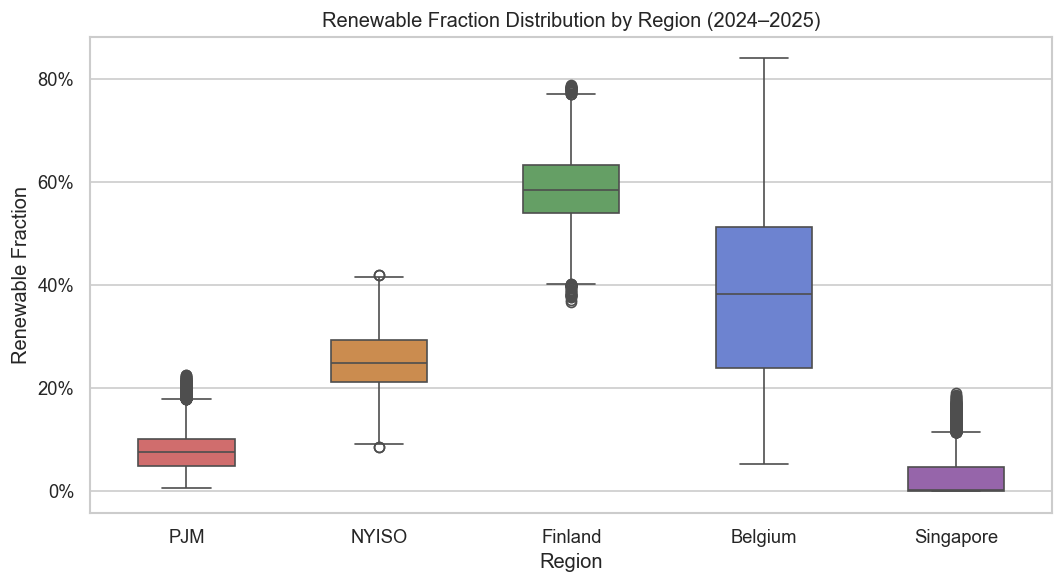

In [12]:
rf_all = pd.concat([df[["rf", "zone"]] for df in data.values()])

# Figure 1: RF distribution boxplot
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=rf_all, x="zone", y="rf", order=zone_order,
            palette=palette, width=0.5, ax=ax)
ax.set_title("Renewable Fraction Distribution by Region (2024–2025)")
ax.set_xlabel("Region")
ax.set_ylabel("Renewable Fraction")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("../data/figures/eda_rf_distribution.png", bbox_inches="tight")
plt.show()

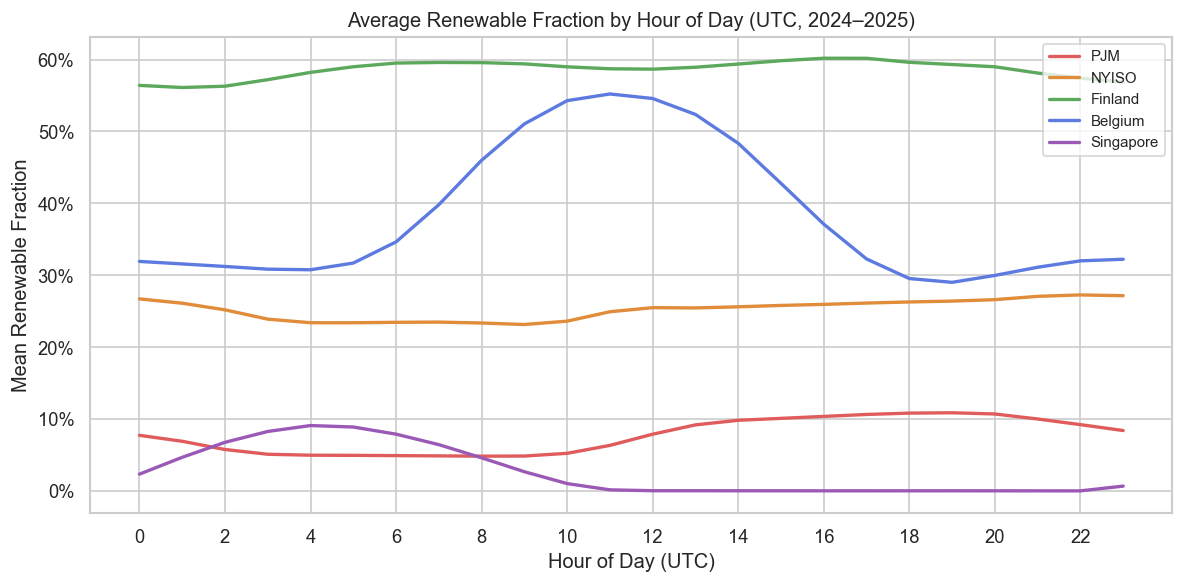

In [13]:
# Figure 2: RF diurnal pattern
fig, ax = plt.subplots(figsize=(10, 5))
for zone, df in data.items():
    rf_hourly = df["rf"].groupby(df.index.hour).mean()
    ax.plot(rf_hourly.index, rf_hourly.values,
            label=ZONES[zone]["label"],
            color=ZONES[zone]["color"], linewidth=2)
ax.set_title("Average Renewable Fraction by Hour of Day (UTC, 2024–2025)")
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Mean Renewable Fraction")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../data/figures/eda_rf_diurnal.png", bbox_inches="tight")
plt.show()

---
## 10. CI–RF Relationship — Deriving the Objective Function Form

Before incorporating RF into the scheduling objective, we need to establish two things empirically: (1) whether RF and CI are systematically related, and (2) what functional form best describes that relationship. The objective function is constructed from these results, not the other way around.

The analysis proceeds in four steps: scatter plots and Pearson correlation establish direction (Section 10.0); OLS regression quantifies the marginal relationship and tests significance (Section 10.1); a functional form comparison tests whether a multiplicative or additive discount better describes the data (Section 10.2); the implied α values then determine whether a single shared parameter is feasible across regions (Section 10.3).

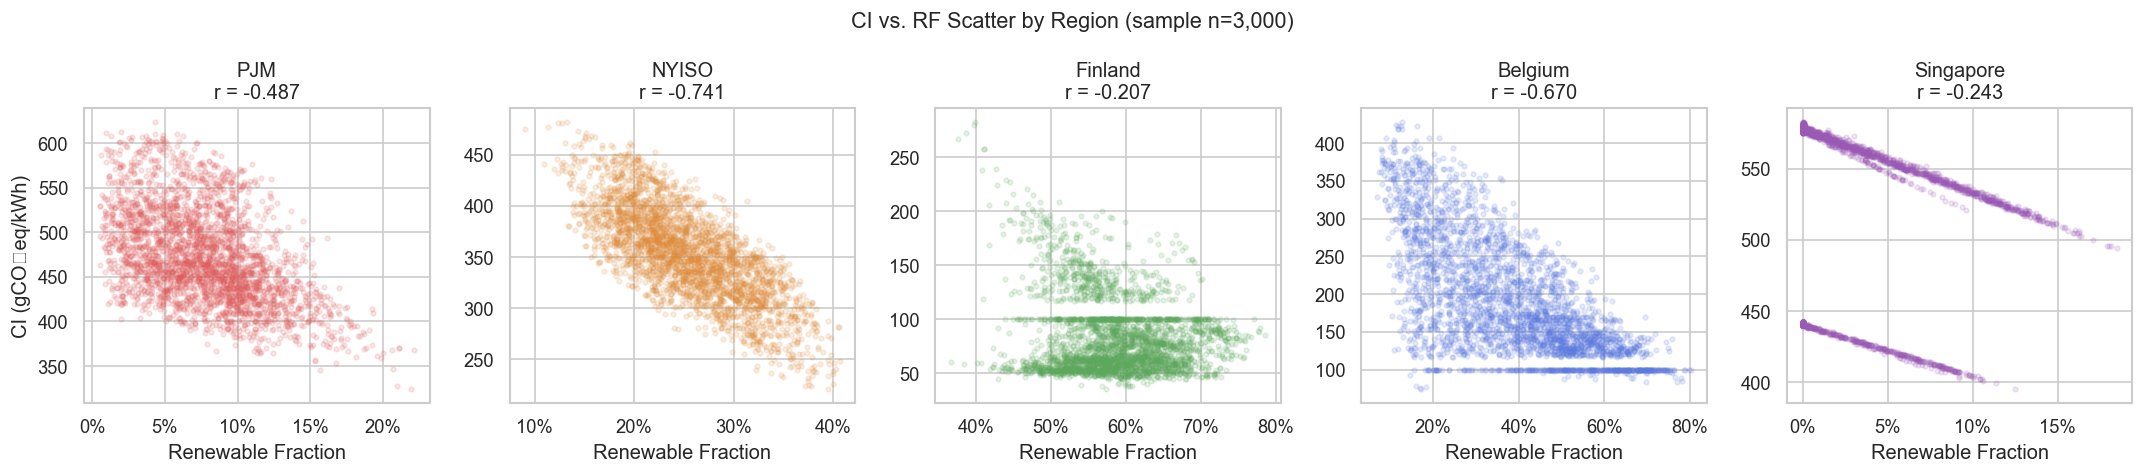


Pearson correlation (CI, RF):
  PJM         r = -0.487
  NYISO       r = -0.741
  Finland     r = -0.207
  Belgium     r = -0.670
  Singapore   r = -0.243


In [14]:
fig, axes = plt.subplots(1, len(ZONES), figsize=(18, 4), sharey=False)

for ax, (zone, df) in zip(axes, data.items()):
    sample = df.sample(min(3000, len(df)), random_state=42)
    corr = df["ci"].corr(df["rf"])
    ax.scatter(sample["rf"], sample["ci"],
               alpha=0.15, s=8, color=ZONES[zone]["color"])
    ax.set_title(f"{ZONES[zone]['label']}\nr = {corr:.3f}")
    ax.set_xlabel("Renewable Fraction")
    ax.set_ylabel("CI (gCO₂eq/kWh)" if ax == axes[0] else "")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.suptitle("CI vs. RF Scatter by Region (sample n=3,000)", fontsize=13)
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_rf_scatter.png", bbox_inches="tight")
plt.show()

print("\nPearson correlation (CI, RF):")
for zone, df in data.items():
    print(f"  {ZONES[zone]['label']:10}  r = {df['ci'].corr(df['rf']):.3f}")

---
### 10.1 OLS Regression: Quantifying the CI–RF Relationship

A scatter plot and Pearson correlation only establish direction and linear strength. To inform the **functional form** of the objective, we need to quantify the marginal relationship: how much does CI decrease per unit increase in RF, and is this effect consistent across regions?

We run OLS regression CI = β₀ + β₁·RF for each region. The slope β₁ gives the average CI reduction per unit RF. The **normalized slope** β₁/CI_mean tests whether the RF effect is proportional to the CI level — a prerequisite for justifying a multiplicative discount form rather than an additive one.

In [16]:
! pip install scipy --quiet
from scipy import stats

reg_results = []
reg_params = {}

for zone, df in data.items():
    x = df["rf"].values
    y = df["ci"].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    ci_mean = df["ci"].mean()
    # implied α under multiplicative form: CI ≈ β₀·(1 - α·RF) → α = -β₁/β₀
    alpha_implied = -slope / intercept
    reg_params[zone] = {"slope": slope, "intercept": intercept, "r": r_value}
    reg_results.append({
        "Region":           ZONES[zone]["label"],
        "CI mean":          round(ci_mean, 1),
        "β₀ (intercept)":  round(intercept, 1),
        "β₁ (slope)":      round(slope, 1),
        "β₁ / CI mean":    round(slope / ci_mean, 3),
        "α implied":        round(alpha_implied, 3),
        "R²":               round(r_value**2, 3),
        "p-value":          f"{p_value:.2e}",
    })

reg_df = pd.DataFrame(reg_results).set_index("Region")
print(reg_df.to_string())
print("""
Interpretation guide:
  β₁         : CI reduction (gCO₂/kWh) per unit increase in RF (0→1 scale)
  β₁/CI mean : normalized slope — consistent across regions → multiplicative form appropriate
  α implied  : -β₁/β₀, the discount weight under CI·(1−α·RF); consistent → single α feasible
""")

           CI mean  β₀ (intercept)  β₁ (slope)  β₁ / CI mean  α implied     R²    p-value
Region                                                                                   
PJM          472.2           524.6      -681.0        -1.442      1.298  0.237   0.00e+00
NYISO        353.7           501.0      -583.4        -1.649      1.164  0.550   0.00e+00
Finland       82.7           145.8      -107.5        -1.299      0.738  0.043  6.74e-169
Belgium      191.2           308.0      -304.5        -1.592      0.989  0.449   0.00e+00
Singapore    533.2           543.2      -377.3        -0.708      0.695  0.059  1.12e-234

Interpretation guide:
  β₁         : CI reduction (gCO₂/kWh) per unit increase in RF (0→1 scale)
  β₁/CI mean : normalized slope — consistent across regions → multiplicative form appropriate
  α implied  : -β₁/β₀, the discount weight under CI·(1−α·RF); consistent → single α feasible



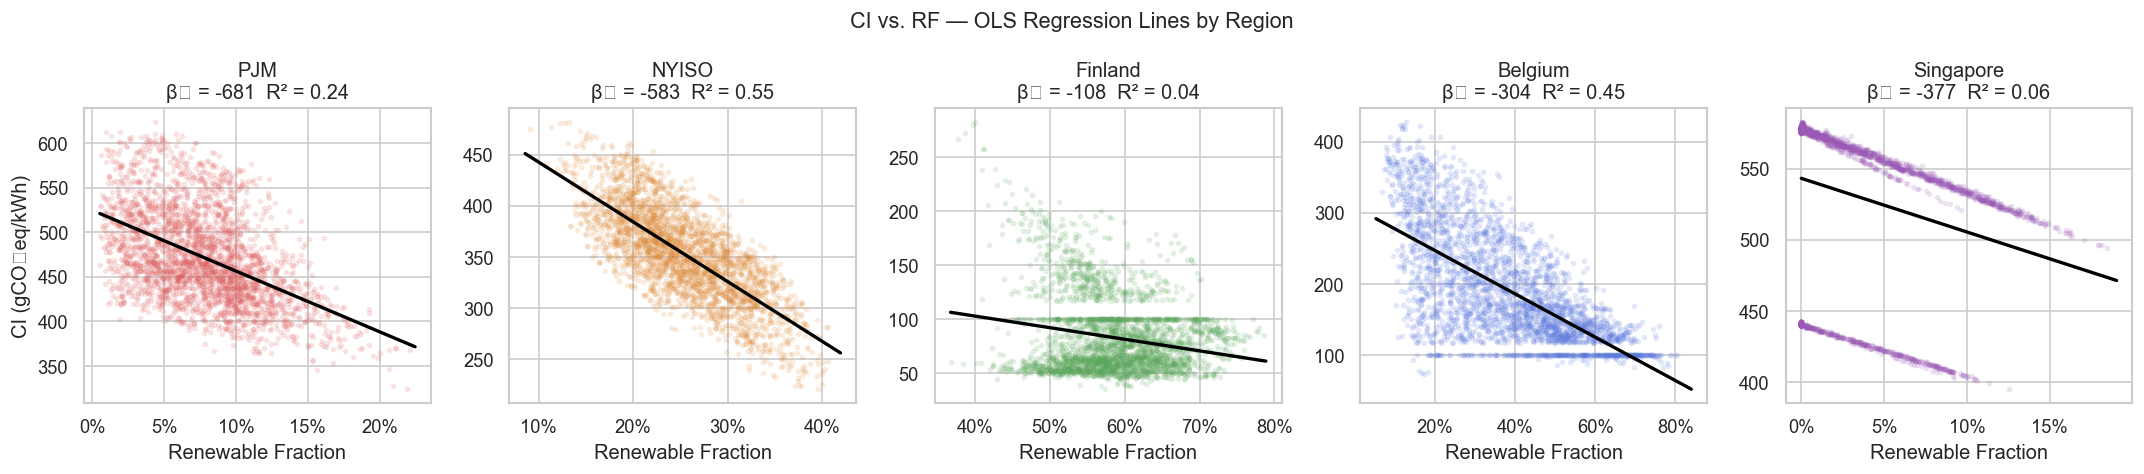

In [17]:
fig, axes = plt.subplots(1, len(ZONES), figsize=(18, 4), sharey=False)

for ax, (zone, df) in zip(axes, data.items()):
    sample = df.sample(min(3000, len(df)), random_state=42)
    p = reg_params[zone]
    rf_range = np.linspace(df["rf"].min(), df["rf"].max(), 100)
    ci_hat = p["intercept"] + p["slope"] * rf_range

    ax.scatter(sample["rf"], sample["ci"],
               alpha=0.12, s=6, color=ZONES[zone]["color"])
    ax.plot(rf_range, ci_hat, color="black", linewidth=2)
    ax.set_title(
        f"{ZONES[zone]['label']}\n"
        f"β₁ = {p['slope']:.0f}  R² = {p['r']**2:.2f}"
    )
    ax.set_xlabel("Renewable Fraction")
    ax.set_ylabel("CI (gCO₂eq/kWh)" if ax == axes[0] else "")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.suptitle("CI vs. RF — OLS Regression Lines by Region", fontsize=13)
plt.tight_layout()
plt.savefig("../data/figures/eda_ci_rf_regression.png", bbox_inches="tight")
plt.show()

---
### 10.2 Functional Form: Multiplicative vs. Additive Discount

Two natural ways to incorporate RF into the objective are:

- **Additive**: effective cost = CI − β·RF — a fixed gCO₂/kWh discount per unit RF, independent of CI level
- **Multiplicative**: effective cost = CI·(1 − α·RF) — a proportional discount; the benefit of RF scales with CI

The multiplicative form is appropriate if the RF effect is *proportional* to the CI level, i.e., a renewable hour in a high-CI grid avoids more carbon than the same RF in a low-CI grid. We test this by checking whether the **normalized slope** β₁/CI_mean is consistent across regions (supporting multiplicative) or whether the **raw slope** β₁ is consistent (supporting additive).

We also compute the mean absolute error (MAE) of each form fitted per region to compare predictive quality.

In [18]:
form_results = []

for zone, df in data.items():
    p = reg_params[zone]
    ci = df["ci"].values
    rf = df["rf"].values
    ci_mean = ci.mean()

    # Additive: CI_hat = β₀ + β₁·RF  (OLS fit already gives best additive)
    ci_hat_add = p["intercept"] + p["slope"] * rf
    mae_add = np.mean(np.abs(ci - ci_hat_add))

    # Multiplicative: CI·(1 - α·RF), α estimated as -β₁/β₀
    alpha = -p["slope"] / p["intercept"]
    ci_hat_mul = ci_mean * (1 - alpha * rf)
    mae_mul = np.mean(np.abs(ci - ci_hat_mul))

    form_results.append({
        "Region":          ZONES[zone]["label"],
        "β₁ (raw slope)":  round(p["slope"], 1),
        "β₁/CI mean":      round(p["slope"] / ci_mean, 3),
        "α (mult.)":       round(alpha, 3),
        "MAE additive":    round(mae_add, 2),
        "MAE multiplicative": round(mae_mul, 2),
        "Better form":     "Additive" if mae_add < mae_mul else "Multiplicative",
    })

form_df = pd.DataFrame(form_results).set_index("Region")
print(form_df.to_string())

# Consistency check: CoV of raw slope vs normalised slope across regions
raw_slopes   = [r["β₁ (raw slope)"] for r in form_results]
norm_slopes  = [r["β₁/CI mean"]     for r in form_results]
cov_raw  = np.std(raw_slopes)  / abs(np.mean(raw_slopes))
cov_norm = np.std(norm_slopes) / abs(np.mean(norm_slopes))
print(f"\nCoV of raw β₁ across regions:        {cov_raw:.3f}")
print(f"CoV of normalised β₁/CI mean:         {cov_norm:.3f}")
print("→ Lower CoV = more consistent across regions")
print("→ If CoV(normalised) < CoV(raw): multiplicative form generalises better")

           β₁ (raw slope)  β₁/CI mean  α (mult.)  MAE additive  MAE multiplicative Better form
Region                                                                                        
PJM                -681.0      -1.442      1.298         36.42               51.83    Additive
NYISO              -583.4      -1.649      1.164         24.18              103.99    Additive
Finland            -107.5      -1.299      0.738         26.35               36.02    Additive
Belgium            -304.5      -1.592      0.989         44.26               75.87    Additive
Singapore          -377.3      -0.708      0.695         49.60               54.66    Additive

CoV of raw β₁ across regions:        0.496
CoV of normalised β₁/CI mean:         0.252
→ Lower CoV = more consistent across regions
→ If CoV(normalised) < CoV(raw): multiplicative form generalises better


---
### 10.3 Implications for the Objective Function

Based on the regression results above, the objective function is constructed as follows:

**Step 1 — Confirm RF adds information.** All five regions show a statistically significant negative slope (p ≪ 0.01), confirming that RF and CI move in opposite directions and that RF carries scheduling-relevant signal beyond CI alone.

**Step 2 — Choose functional form.** If the normalised slope β₁/CI_mean is more consistent across regions than the raw slope β₁ (lower CoV), the multiplicative form generalises better across grids with structurally different CI levels. The MAE comparison provides a per-region fit check.

**Step 3 — Derive α.** Under the multiplicative form CI·(1 − α·RF), the regression implies α ≈ −β₁/β₀ per region. If these values cluster tightly, a single shared α is feasible; if they diverge significantly, region-specific α values are warranted.

**Step 4 — Handle weak-correlation regions.** For any region where |r| < 0.2 or the implied α is not statistically distinguishable from zero, α is set to zero — the model reverts to pure CI minimisation for that region.

This analysis produces the empirically grounded objective:

$$\min \sum_{r} \sum_{t} x_{r,t} \cdot \mathrm{CI}_r(t) \cdot \bigl(1 - \alpha_r \cdot \mathrm{RF}_r(t)\bigr)$$

where α_r is either a single shared value (if α_implied is consistent across regions) or region-specific (if not), and is set to zero for regions with weak CI–RF correlation.

---
## 11. Key Findings & Implications for the Optimization Model

This section consolidates the EDA findings and maps them directly to modeling decisions.

In [19]:
summary = []
for zone, df in data.items():
    cv = df["ci"].std() / df["ci"].mean()
    diurnal_range = df["ci"].groupby(df.index.hour).mean()
    ci_rf_corr = df["ci"].corr(df["rf"])
    summary.append({
        "Region":         ZONES[zone]["label"],
        "CI mean":        round(df["ci"].mean(), 1),
        "CV":             round(cv, 3),
        "Diurnal range":  round(diurnal_range.max() - diurnal_range.min(), 1),
        "RF mean %":      round(df["rf"].mean() * 100, 1),
        "CI–RF corr":     round(ci_rf_corr, 3),
        "CI variability": "High" if cv > 0.15 else ("Medium" if cv > 0.08 else "Low"),
    })

summary_df = pd.DataFrame(summary).set_index("Region")
print(summary_df.to_string())
print("""
Key takeaways (post-hoc observations):
1. Finland and Belgium show the highest CV — post-hoc analysis will test whether their backtested
   savings are correspondingly higher than lower-CV regions
2. Singapore's low CV confirms that even an optimal policy will achieve limited carbon savings there;
   it serves as a structural control case, not a failure of the model
3. CI and RF are negatively correlated in all regions
   → RF adds discriminating power: low-CI + high-RF hours are genuinely cleaner
   → The RF weighting term in the objective is empirically justified (see Section 10)
""")

           CI mean     CV  Diurnal range  RF mean %  CI–RF corr CI variability
Region                                                                        
PJM          472.2  0.110           36.7        7.7      -0.487         Medium
NYISO        353.7  0.125           31.2       25.2      -0.741         Medium
Finland       82.7  0.420            5.1       58.6      -0.207           High
Belgium      191.2  0.398           72.4       38.3      -0.670           High
Singapore    533.2  0.112           41.0        2.7      -0.243         Medium

Key takeaways (post-hoc observations):
1. Finland and Belgium show the highest CV — post-hoc analysis will test whether their backtested
   savings are correspondingly higher than lower-CV regions
2. Singapore's low CV confirms that even an optimal policy will achieve limited carbon savings there;
   it serves as a structural control case, not a failure of the model
3. CI and RF are negatively correlated in all regions
   → RF adds discrimina